[*********************100%***********************]  1 of 1 completed



Model Performance
Mean Absolute Error: 2.88
R2 Score: 0.98


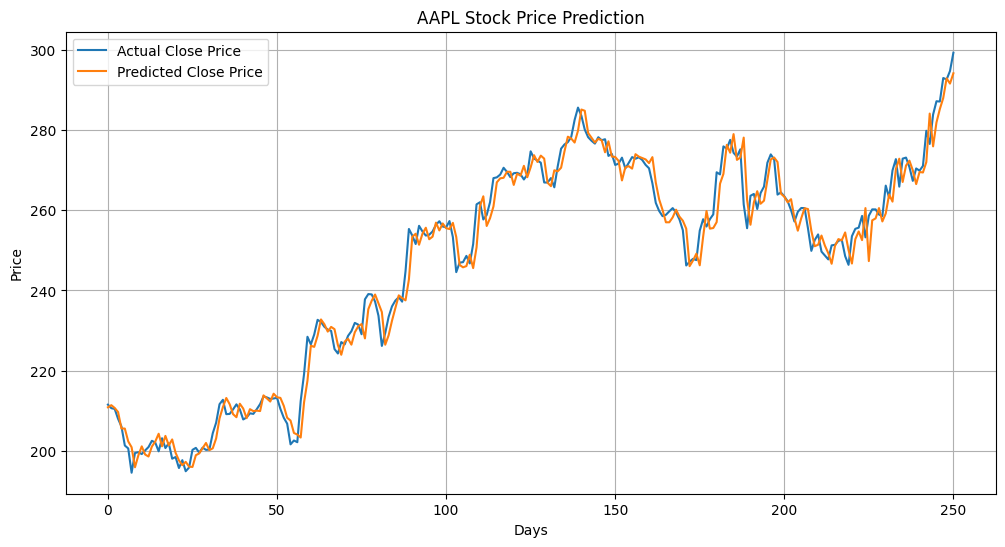


Predicted Next Day Closing Price:
298.91


In [8]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

ticker="AAPL"
data=yf.download(ticker,period="5y",interval="1d")
X=data[['Open','High','Low','Volume']]
Y=data['Close'].shift(-1)
X=X[:-1]
Y=Y[:-1]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,shuffle=False)
linear_model=LinearRegression()
model_train=linear_model.fit(X_train,Y_train)
y_predict=model_train.predict(X_test)
mae = mean_absolute_error(Y_test, y_predict)
r2 = r2_score(Y_test, y_predict)

print("\nModel Performance")
print("Mean Absolute Error:", round(mae, 2))
print("R2 Score:", round(r2, 2))
plt.figure(figsize=(12,6))

plt.plot(
    Y_test.values,
    label="Actual Close Price"
)

plt.plot(
    y_predict,
    label="Predicted Close Price"
)

plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Price")

plt.legend()
plt.grid(True)

plt.show()
latest_features = data[['Open', 'High', 'Low', 'Volume']].tail(1)

next_day_price = linear_model.predict(latest_features)

print("\nPredicted Next Day Closing Price:")
print(round(next_day_price[0][0], 2))

